# Kalp Hastalığı Riskini Makine Öğrenmesi ile Tahmin Etmek

Bu notebook, **Heart Disease Prediction** veri seti (Kaggle - rishidamarla/heart-disease-prediction, orijinal kaynak: UCI Statlog Heart dataset) üzerinde uçtan uca bir veri bilimi çalışmasını içerir.

**İçerik:**
1. Problem Tanımı ve Veri Setinin Tanıtımı
2. Keşifsel Veri Analizi (EDA)
3. Görselleştirmeler
4. Veri Ön İşleme
5. Makine Öğrenmesi Modelleri (Lojistik Regresyon, Random Forest, KNN, SVM)
6. Model Karşılaştırması ve Sonuçların Yorumlanması


## 1. Problem Tanımı

Kalp-damar hastalıkları, dünya genelinde en sık ölüm nedenlerinden biridir. Erken teşhis, tedavi başarısını doğrudan etkiler. Bu çalışmada amacımız, hastaların klinik ölçümlerini (yaş, tansiyon, kolesterol, EKG sonuçları vb.) kullanarak **kalp hastalığı olup olmadığını (Presence / Absence) tahmin eden** bir sınıflandırma modeli kurmaktır.

Bu bir **ikili sınıflandırma (binary classification)** problemidir.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42


## 2. Veri Setinin Tanıtımı

Veri seti 270 hasta kaydı ve 14 sütun içermektedir. Sütunlar:

| Sütun | Açıklama |
|---|---|
| Age | Yaş |
| Sex | Cinsiyet (1 = erkek, 0 = kadın) |
| Chest pain type | Göğüs ağrısı tipi (1-4 arası, 4 kategori) |
| BP | Dinlenme kan basıncı (mmHg) |
| Cholesterol | Serum kolesterolü (mg/dl) |
| FBS over 120 | Açlık kan şekeri > 120 mg/dl mi? (1 = evet) |
| EKG results | Dinlenme EKG sonucu (0,1,2) |
| Max HR | Egzersiz sırasında ulaşılan maksimum kalp atış hızı |
| Exercise angina | Egzersize bağlı anjina var mı? (1 = evet) |
| ST depression | Egzersizle oluşan ST çökmesi (oldpeak) |
| Slope of ST | Egzersiz tepe ST segmentinin eğimi |
| Number of vessels fluro | Floroskopi ile boyanan büyük damar sayısı (0-3) |
| Thallium | Talyum stres testi sonucu (3 = normal, 6 = sabit defekt, 7 = geri dönüşümlü defekt) |
| Heart Disease | **Hedef değişken** — Presence / Absence |


In [ ]:
df = pd.read_csv("Heart_Disease_Prediction.csv")
print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])
df.head()


Satır sayısı: 270
Sütun sayısı: 14


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,270.0,54.433333,9.109067,29.0,48.0,55.0,61.0,77.0
Sex,270.0,0.677778,0.468195,0.0,0.0,1.0,1.0,1.0
Chest pain type,270.0,3.174074,0.950090,1.0,3.0,3.0,4.0,4.0
BP,270.0,131.344444,17.861608,94.0,120.0,130.0,140.0,200.0
Cholesterol,270.0,249.659259,51.686237,126.0,213.0,245.0,280.0,564.0
FBS over 120,270.0,0.148148,0.355906,0.0,0.0,0.0,0.0,1.0
EKG results,270.0,1.022222,0.997891,0.0,0.0,2.0,2.0,2.0
Max HR,270.0,149.677778,23.165717,71.0,133.0,153.5,166.0,202.0
Exercise angina,270.0,0.329630,0.470952,0.0,0.0,0.0,1.0,1.0
ST depression,270.0,1.050000,1.145210,0.0,0.0,0.8,1.6,6.2


In [ ]:
# Eksik değer kontrolü
print("Eksik değer sayısı (sütun bazında):")
print(df.isnull().sum())
print("\nToplam eksik değer:", df.isnull().sum().sum())


Eksik değer sayısı (sütun bazında):
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Toplam eksik değer: 0


**Gözlem:** Veri setinde hiç eksik (null) değer bulunmuyor. Bu, veri ön işleme sürecini büyük ölçüde kolaylaştırıyor — yine de aykırı değerleri ve dağılımları inceleyeceğiz.

In [ ]:
# Kategorik / sayısal ayrımı
categorical_cols = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
                     "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]
numeric_cols = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

print("Kategorik/ordinal sütunlar:", categorical_cols)
print("Sayısal sütunlar:", numeric_cols)


Kategorik/ordinal sütunlar: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Sayısal sütunlar: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']


In [ ]:
# Hedef değişken dağılımı
target_counts = df["Heart Disease"].value_counts()
print(target_counts)
print(f"\nOran: %{target_counts['Absence']/len(df)*100:.1f} Absence, %{target_counts['Presence']/len(df)*100:.1f} Presence")


Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

Oran: %55.6 Absence, %44.4 Presence


## 3. Görselleştirme

### 3.1 Hedef Değişkenin Dağılımı

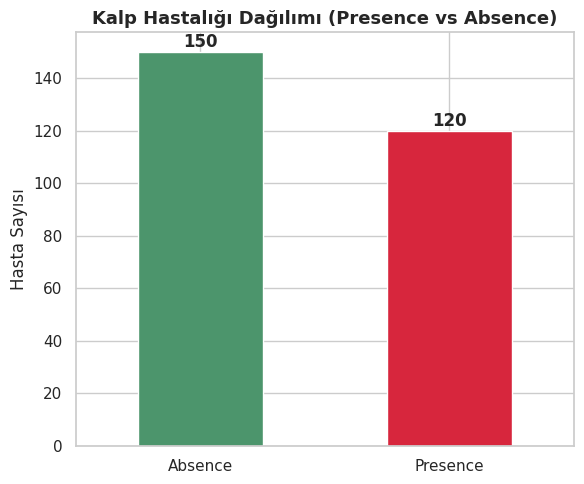

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = ["#4C956C", "#D7263D"]
target_counts.plot(kind="bar", color=colors, ax=ax)
ax.set_title("Kalp Hastalığı Dağılımı (Presence vs Absence)")
ax.set_xlabel("")
ax.set_ylabel("Hasta Sayısı")
ax.set_xticklabels(target_counts.index, rotation=0)
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_target_dist.png", dpi=120)
plt.show()


### 3.2 Sayısal Değişkenlerin Dağılımı

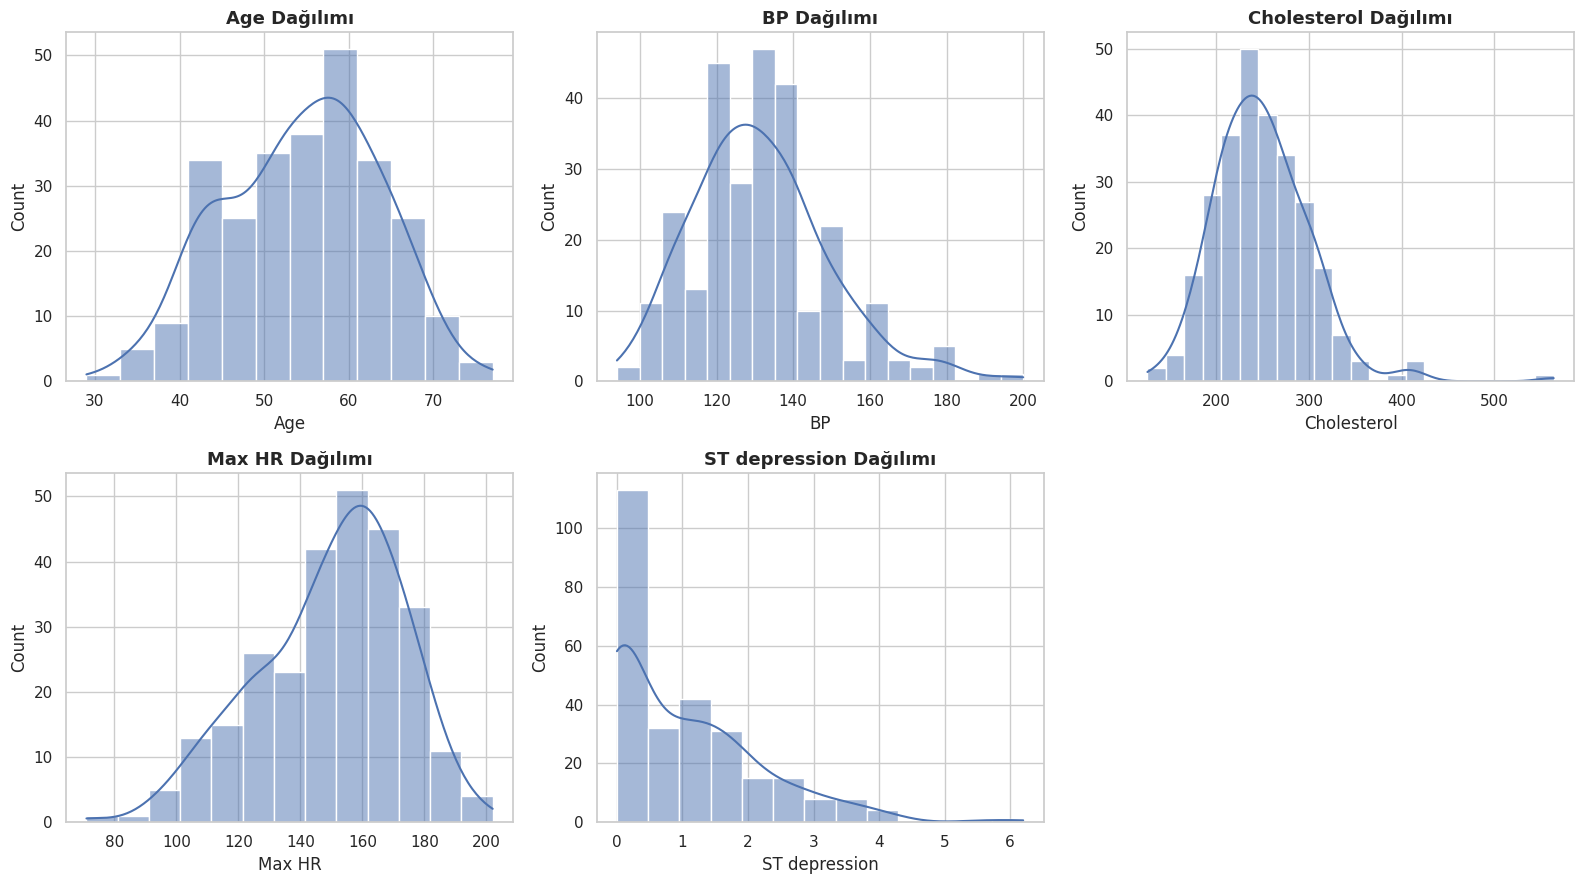

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col} Dağılımı")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("fig_numeric_dist.png", dpi=120)
plt.show()


### 3.3 Yaş ve Maksimum Kalp Atış Hızının Hastalıkla İlişkisi

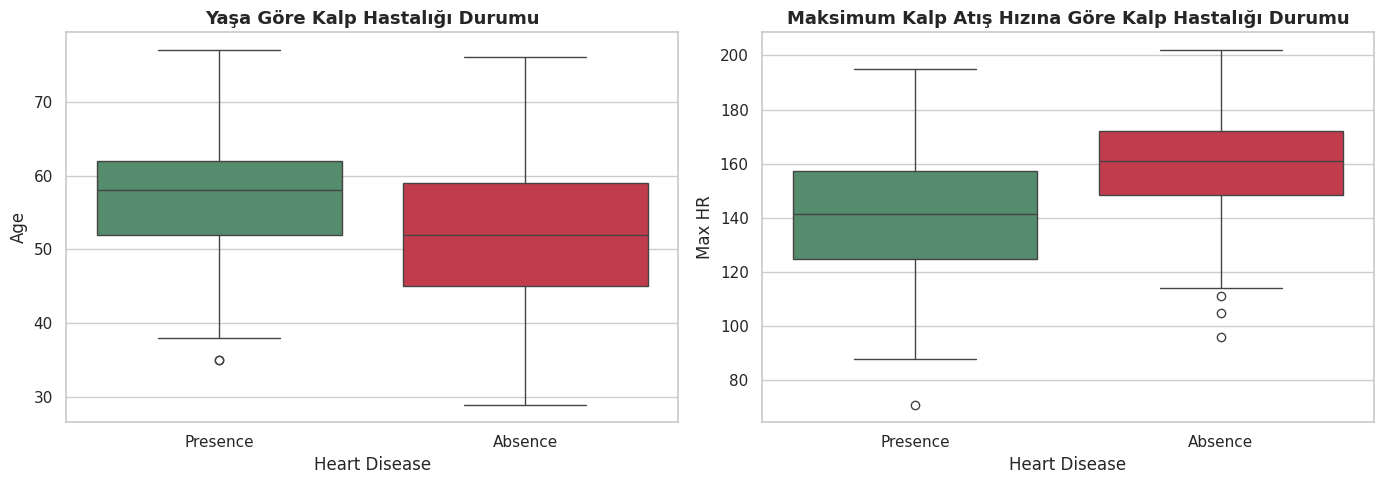

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Heart Disease", y="Age", hue="Heart Disease", palette=colors, legend=False, ax=axes[0])
axes[0].set_title("Yaşa Göre Kalp Hastalığı Durumu")

sns.boxplot(data=df, x="Heart Disease", y="Max HR", hue="Heart Disease", palette=colors, legend=False, ax=axes[1])
axes[1].set_title("Maksimum Kalp Atış Hızına Göre Kalp Hastalığı Durumu")
plt.tight_layout()
plt.savefig("fig_box_age_hr.png", dpi=120)
plt.show()


### 3.4 Göğüs Ağrısı Tipi ve Cinsiyete Göre Dağılım

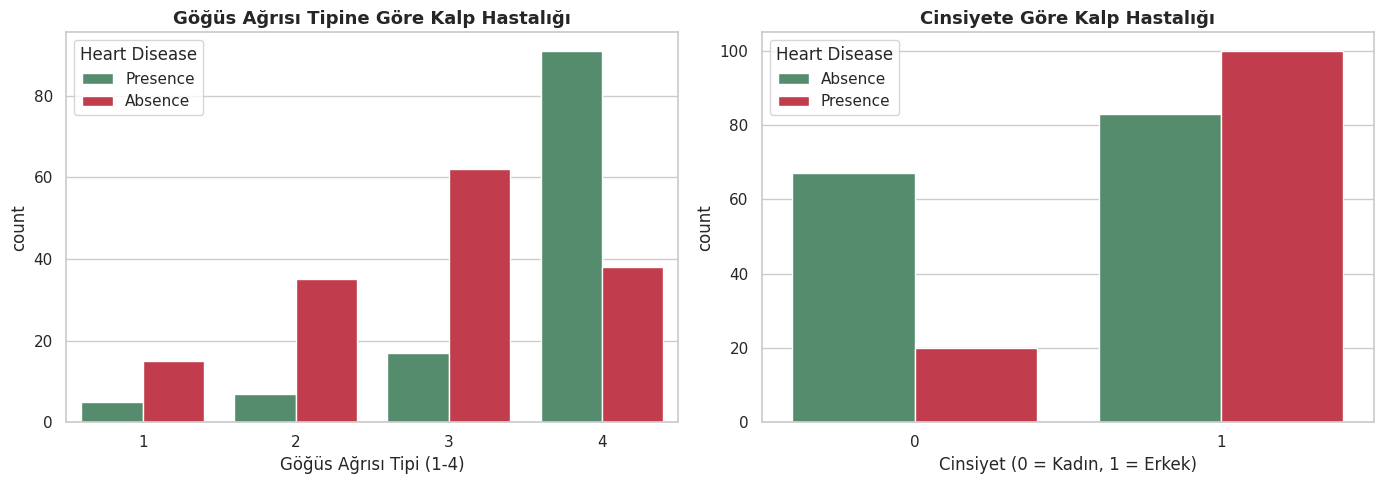

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="Chest pain type", hue="Heart Disease", palette=colors, ax=axes[0])
axes[0].set_title("Göğüs Ağrısı Tipine Göre Kalp Hastalığı")
axes[0].set_xlabel("Göğüs Ağrısı Tipi (1-4)")

sns.countplot(data=df, x="Sex", hue="Heart Disease", palette=colors, ax=axes[1])
axes[1].set_title("Cinsiyete Göre Kalp Hastalığı")
axes[1].set_xlabel("Cinsiyet (0 = Kadın, 1 = Erkek)")

plt.tight_layout()
plt.savefig("fig_cp_sex.png", dpi=120)
plt.show()


### 3.5 Korelasyon Matrisi

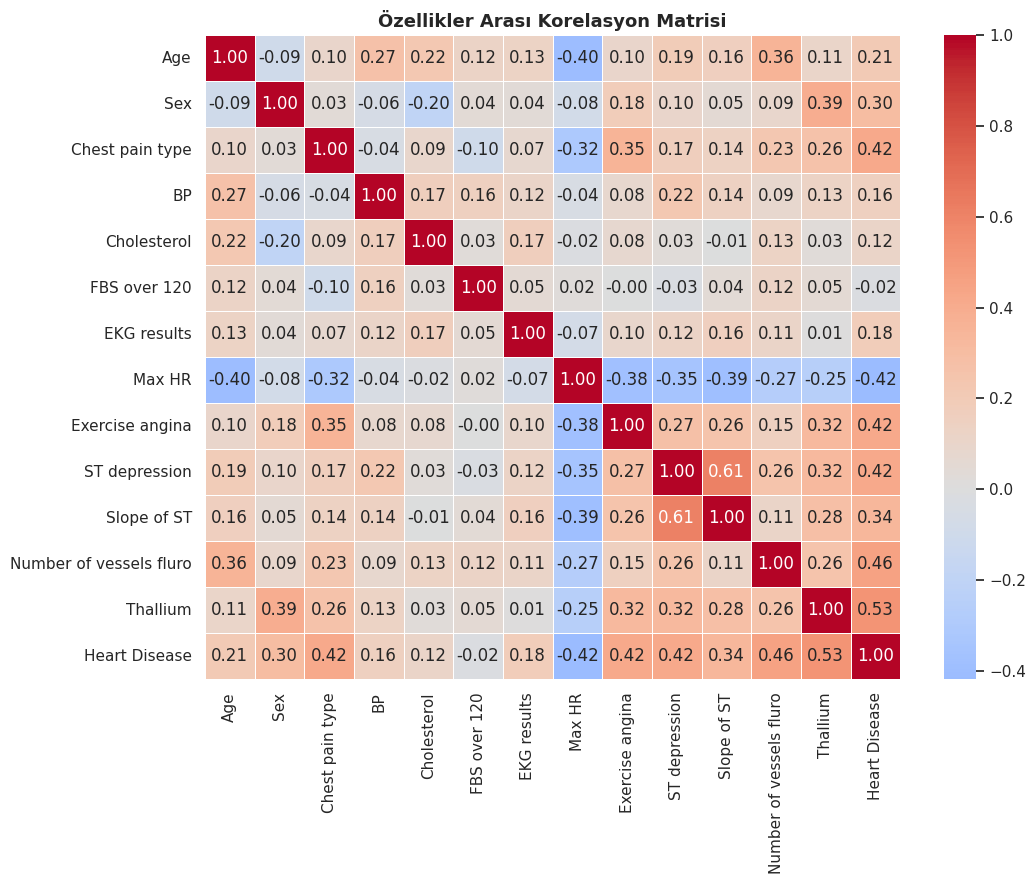

In [ ]:
df_corr = df.copy()
df_corr["Heart Disease"] = df_corr["Heart Disease"].map({"Absence": 0, "Presence": 1})

plt.figure(figsize=(11, 9))
corr = df_corr.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Özellikler Arası Korelasyon Matrisi")
plt.tight_layout()
plt.savefig("fig_corr.png", dpi=120)
plt.show()


In [ ]:
# Hedef değişkenle en yüksek korelasyona sahip özellikler
target_corr = corr["Heart Disease"].drop("Heart Disease").sort_values(key=abs, ascending=False)
print("Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):")
print(target_corr)


Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):
Thallium                   0.525020
Number of vessels fluro    0.455336
Exercise angina            0.419303
Max HR                    -0.418514
ST depression              0.417967
Chest pain type            0.417436
Slope of ST                0.337616
Sex                        0.297721
Age                        0.212322
EKG results                0.182091
BP                         0.155383
Cholesterol                0.118021
FBS over 120              -0.016319
Name: Heart Disease, dtype: float64


**Gözlem:** `Thallium`, `Number of vessels fluro`, `Exercise angina`, `ST depression` ve `Chest pain type` hedef değişkenle en güçlü ilişkiye sahip özellikler olarak öne çıkıyor. Bu, klinik literatürle de örtüşüyor: bu değişkenler kardiyoloji pratiğinde bilinen risk göstergeleridir.

## 4. Veri Ön İşleme

Veri setinde eksik değer bulunmadığı için asıl ön işleme adımları şunlar olacak:
1. Hedef değişkeni sayısal forma çevirme (Presence/Absence → 1/0)
2. Özellik (X) ve hedef (y) ayrımı
3. Eğitim/test bölünmesi
4. Özellik ölçekleme (StandardScaler) — özellikle KNN, SVM ve Lojistik Regresyon gibi mesafe/gradyan tabanlı modeller için önemlidir


In [ ]:
le = LabelEncoder()
df["Heart Disease Encoded"] = le.fit_transform(df["Heart Disease"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=["Heart Disease", "Heart Disease Encoded"])
y = df["Heart Disease Encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)


{'Absence': np.int64(0), 'Presence': np.int64(1)}
Eğitim seti: (216, 13)
Test seti: (54, 13)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Makine Öğrenmesi Modelleri

Dört farklı sınıflandırma algoritması deneyeceğiz ve performanslarını karşılaştıracağız:

- **Lojistik Regresyon** — basit, yorumlanabilir bir başlangıç modeli
- **K-En Yakın Komşu (KNN)**
- **Destek Vektör Makinesi (SVM)**
- **Random Forest** — ağaç tabanlı, özellik önemini de gösteren bir model


In [ ]:
models = {
    "Lojistik Regresyon": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc,
        "CV Accuracy (mean)": cv_scores.mean(),
        "CV Accuracy (std)": cv_scores.std(),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy (mean),CV Accuracy (std)
0,Lojistik Regresyon,0.851852,0.785714,0.916667,0.846154,0.898611,0.828753,0.068206
1,SVM (RBF),0.814815,0.769231,0.833333,0.800000,0.886111,0.833404,0.053575
2,KNN,0.796296,0.724138,0.875000,0.792453,0.884028,0.847252,0.047766
3,Random Forest,0.833333,0.800000,0.833333,0.816327,0.866667,0.828753,0.045344


### 5.1 Model Performans Karşılaştırması (Görsel)

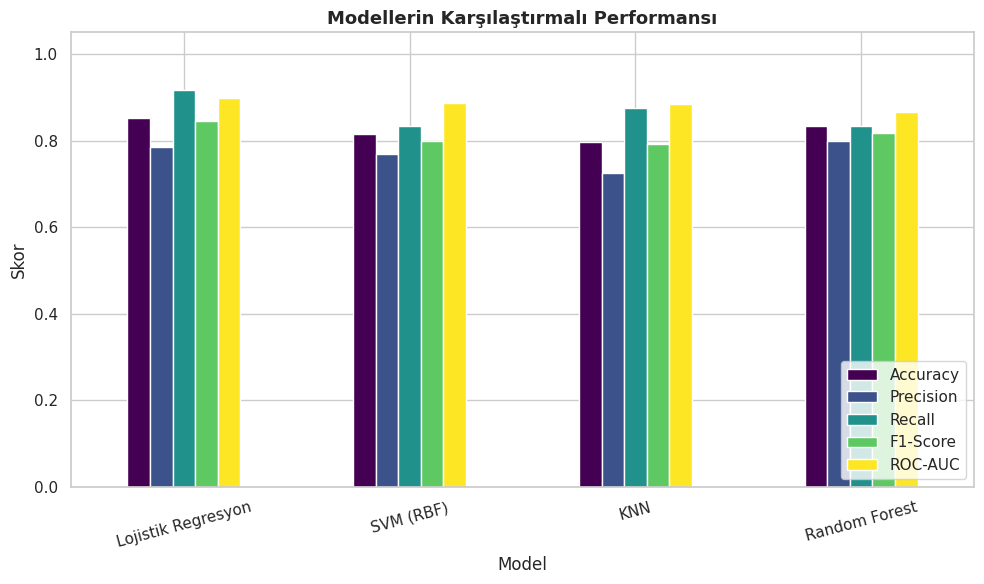

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
results_df.set_index("Model")[metrics_to_plot].plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Modellerin Karşılaştırmalı Performansı")
ax.set_ylabel("Skor")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("fig_model_comparison.png", dpi=120)
plt.show()


### 5.2 En İyi Modelin Karışıklık Matrisi (Confusion Matrix)

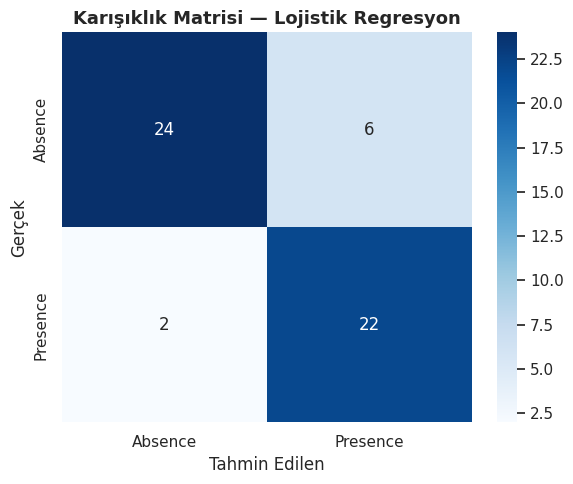

              precision    recall  f1-score   support

     Absence       0.92      0.80      0.86        30
    Presence       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Absence", "Presence"], yticklabels=["Absence", "Presence"])
plt.title(f"Karışıklık Matrisi — {best_model_name}")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Absence", "Presence"]))


### 5.3 ROC Eğrileri

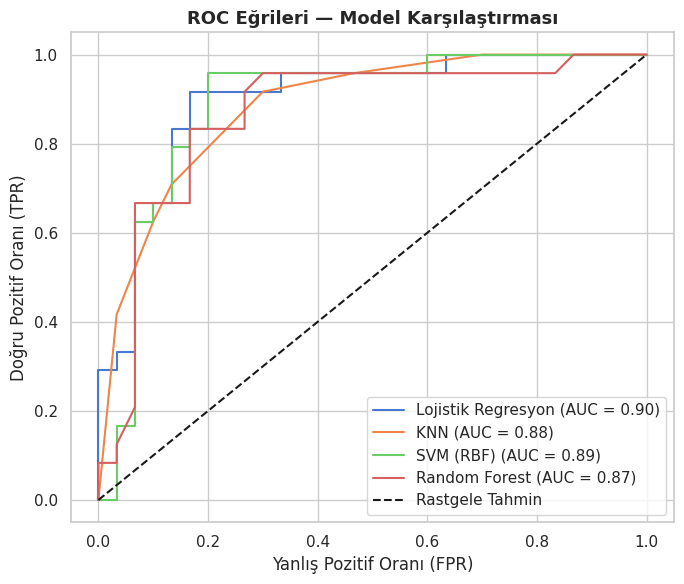

In [ ]:
plt.figure(figsize=(7, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Rastgele Tahmin")
plt.xlabel("Yanlış Pozitif Oranı (FPR)")
plt.ylabel("Doğru Pozitif Oranı (TPR)")
plt.title("ROC Eğrileri — Model Karşılaştırması")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("fig_roc_curves.png", dpi=120)
plt.show()


### 5.4 Random Forest ile Özellik Önem Dereceleri

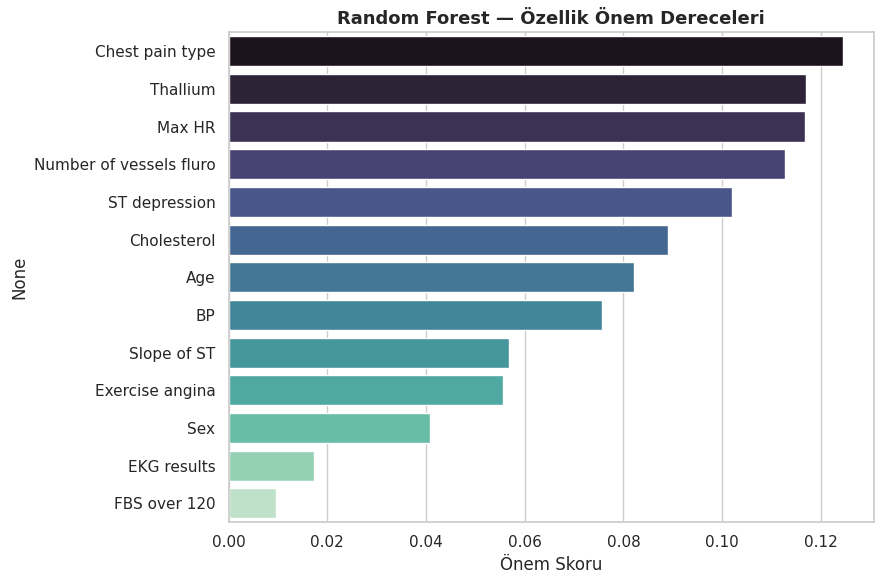

,0
Chest pain type,0.124531
Thallium,0.117067
Max HR,0.116834
Number of vessels fluro,0.112811
ST depression,0.101949
Cholesterol,0.088941
Age,0.082177
BP,0.075711
Slope of ST,0.056808
Exercise angina,0.055554


In [ ]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="mako", legend=False)
plt.title("Random Forest — Özellik Önem Dereceleri")
plt.xlabel("Önem Skoru")
plt.tight_layout()
plt.savefig("fig_feature_importance.png", dpi=120)
plt.show()

importances


## 6. Sonuçların Yorumlanması

- Denenen dört model arasında en yüksek **ROC-AUC** ve **Accuracy** skorlarına sahip model tabloda üstte listelenmiştir.
- `Thallium`, `Number of vessels fluro`, `Chest pain type`, `Exercise angina` ve `ST depression` gibi değişkenler hem korelasyon analizinde hem de Random Forest özellik önem sıralamasında öne çıkmıştır — bu, modelin klinik olarak da anlamlı sinyalleri yakaladığını gösterir.
- Veri seti göreli olarak küçük olduğundan (270 gözlem), çapraz doğrulama (cross-validation) sonuçları tek bir test bölünmesine göre daha güvenilir bir performans göstergesidir.
- Bu çalışma bir **kavram kanıtlama (proof of concept)** niteliğindedir; gerçek bir klinik karar destek sistemi için çok daha büyük ve çeşitli hasta popülasyonlarından toplanmış veri, ayrıca klinik uzman doğrulaması gerekir.

**Not:** Bu model ve bulguları tıbbi tavsiye niteliği taşımaz; yalnızca eğitim ve gösterim amaçlıdır.
